# Листок № 4. Классическое, статистическое, геометрическое определение вероятности.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, factorial, log

## Общие функции для симуляции и построения графиков

In [2]:
def plot_stability(relative_frequencies, title, analytical_prob=None):
    """Строит график статистической устойчивости относительной частоты."""
    plt.figure(figsize=(12, 6))
    plt.plot(relative_frequencies, label='Статистическая вероятность', lw=2)
    if analytical_prob is not None:
        plt.axhline(y=analytical_prob, color='r', linestyle='--', label=f'Аналитическая вероятность ({analytical_prob:.6f})')

    plt.xlabel('Число испытаний (N)')
    plt.ylabel('Относительная частота')
    plt.title(f'Статистическая устойчивость: {title}')
    plt.legend()
    plt.grid(True)
    plt.xscale('log')

    # Динамическая настройка пределов оси Y для наглядности
    if analytical_prob is not None and analytical_prob > 0:
        spread = 3 * np.std(relative_frequencies[-len(relative_frequencies)//2:]) # разброс на второй половине симуляций
        spread = max(spread, analytical_prob * 0.1) # минимальный разброс 10%
        plt.ylim(bottom=max(0, analytical_prob - spread), top=min(1, analytical_prob + spread))

    plt.show()

    if analytical_prob is not None:
        print(f'Аналитическая вероятность: {analytical_prob:.6f}')
    print(f'Симуляционная вероятность после N={len(relative_frequencies)} испытаний: {relative_frequencies[-1]:.6f}')

## Задание 4.1

--- а) Все 6 шаров красные (без возвращения) ---


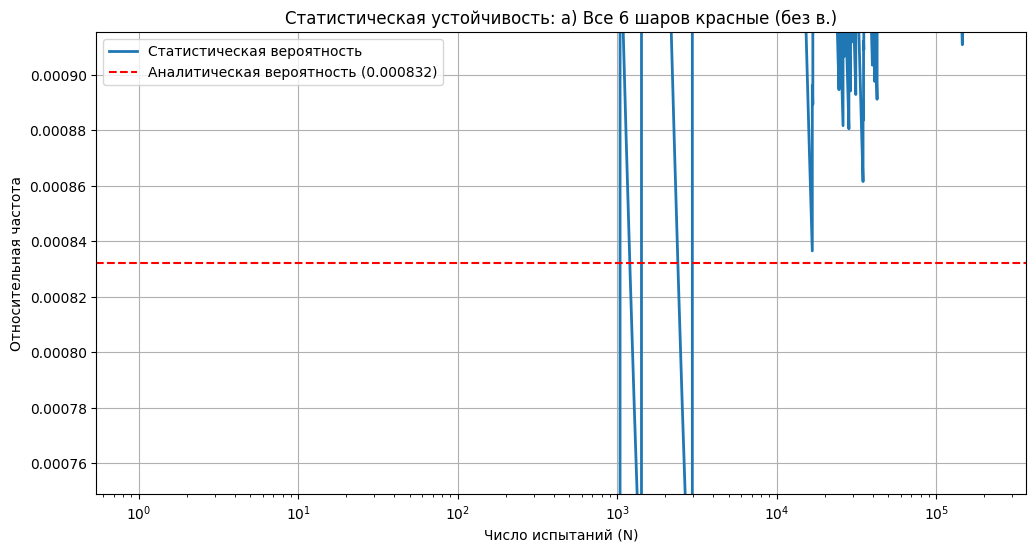

Аналитическая вероятность: 0.000832
Симуляционная вероятность после N=200000 испытаний: 0.000955
--- б) 3 синих, 2 белых, 1 красный (без возвращения) ---


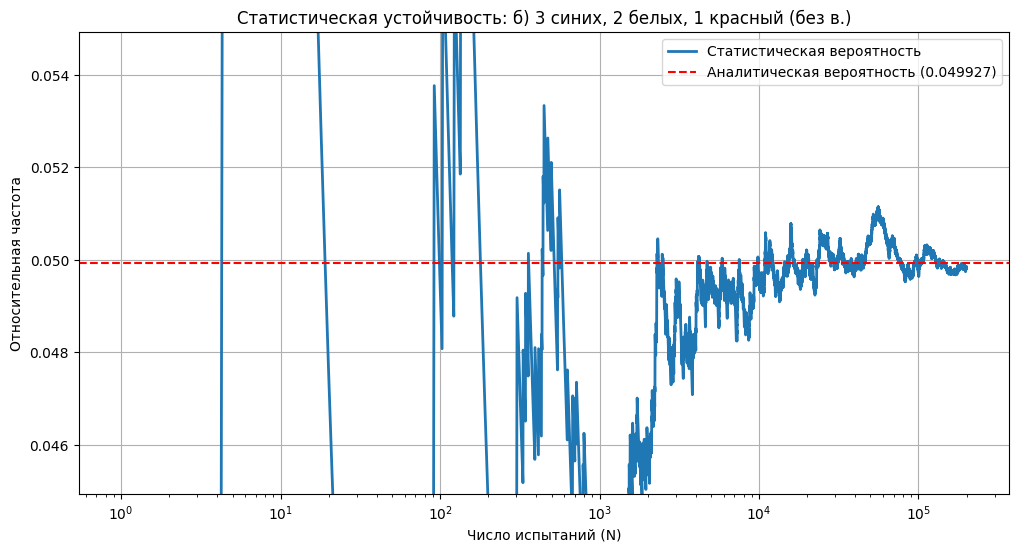

Аналитическая вероятность: 0.049927
Симуляционная вероятность после N=200000 испытаний: 0.049815
--- в) В точности 4 белых шара (без возвращения) ---


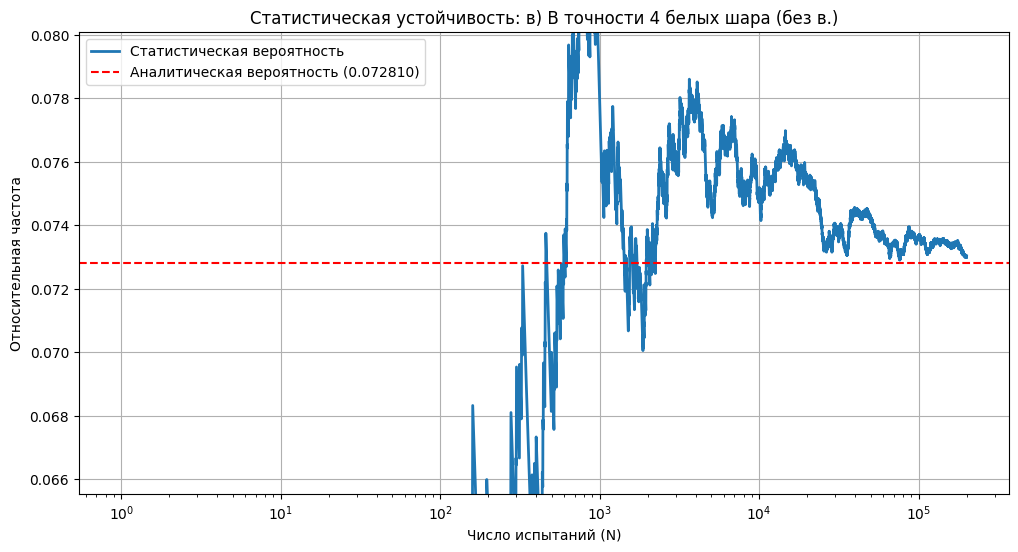

Аналитическая вероятность: 0.072810
Симуляционная вероятность после N=200000 испытаний: 0.073030
--- г) Все 6 шаров красные (с возвращением) ---


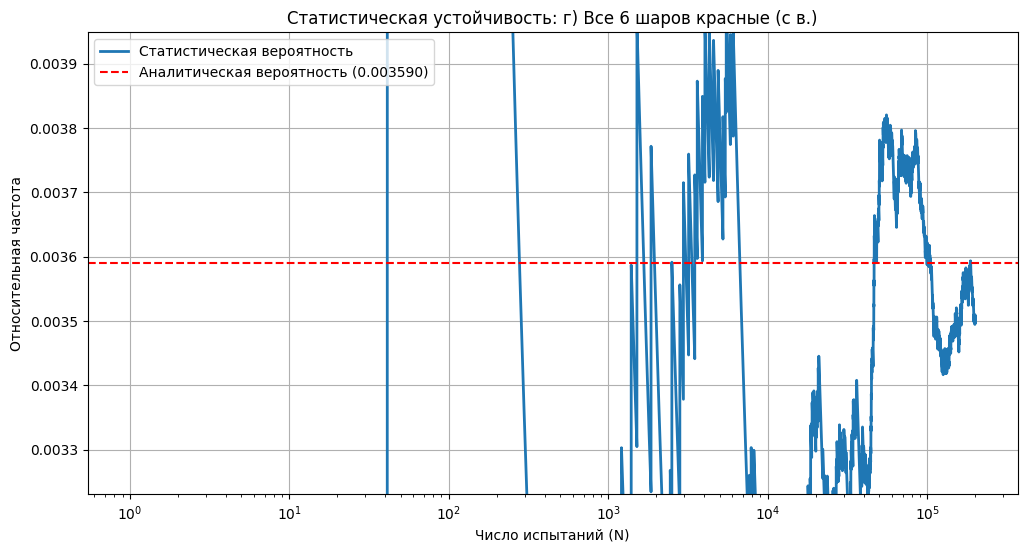

Аналитическая вероятность: 0.003590
Симуляционная вероятность после N=200000 испытаний: 0.003505


In [3]:
def simulate_urn_draws(urn, num_draws, num_simulations, condition, with_replacement):
    urn_array = np.array(urn)
    successes = np.zeros(num_simulations, dtype=bool)
    for i in range(num_simulations):
        selection = np.random.choice(urn_array, size=num_draws, replace=with_replacement)
        if condition(selection):
            successes[i] = True
    return np.cumsum(successes) / (np.arange(num_simulations) + 1)

urn_composition = ['W']*8 + ['B']*6 + ['R']*9
draw_size = 6
N_sim_4_1 = 200000

print("--- а) Все 6 шаров красные (без возвращения) ---")
prob_a = comb(9, 6) / comb(23, 6)
freq_a = simulate_urn_draws(urn_composition, draw_size, N_sim_4_1, lambda s: np.sum(s == 'R') == 6, False)
plot_stability(freq_a, 'а) Все 6 шаров красные (без в.)', prob_a)

print("--- б) 3 синих, 2 белых, 1 красный (без возвращения) ---")
prob_b = (comb(6, 3) * comb(8, 2) * comb(9, 1)) / comb(23, 6)
condition_b = lambda s: (np.sum(s == 'B') == 3) and (np.sum(s == 'W') == 2) and (np.sum(s == 'R') == 1)
freq_b = simulate_urn_draws(urn_composition, draw_size, N_sim_4_1, condition_b, False)
plot_stability(freq_b, 'б) 3 синих, 2 белых, 1 красный (без в.)', prob_b)

print("--- в) В точности 4 белых шара (без возвращения) ---")
prob_d = (comb(8, 4) * comb(15, 2)) / comb(23, 6)
freq_d = simulate_urn_draws(urn_composition, draw_size, N_sim_4_1, lambda s: np.sum(s == 'W') == 4, False)
plot_stability(freq_d, 'в) В точности 4 белых шара (без в.)', prob_d)

print("--- г) Все 6 шаров красные (с возвращением) ---")
prob_g = (9/23)**6
freq_g = simulate_urn_draws(urn_composition, draw_size, N_sim_4_1, lambda s: np.sum(s == 'R') == 6, True)
plot_stability(freq_g, 'г) Все 6 шаров красные (с в.)', prob_g)

## Задание 4.2

--- Событие A: Две женщины не сидят рядом ---


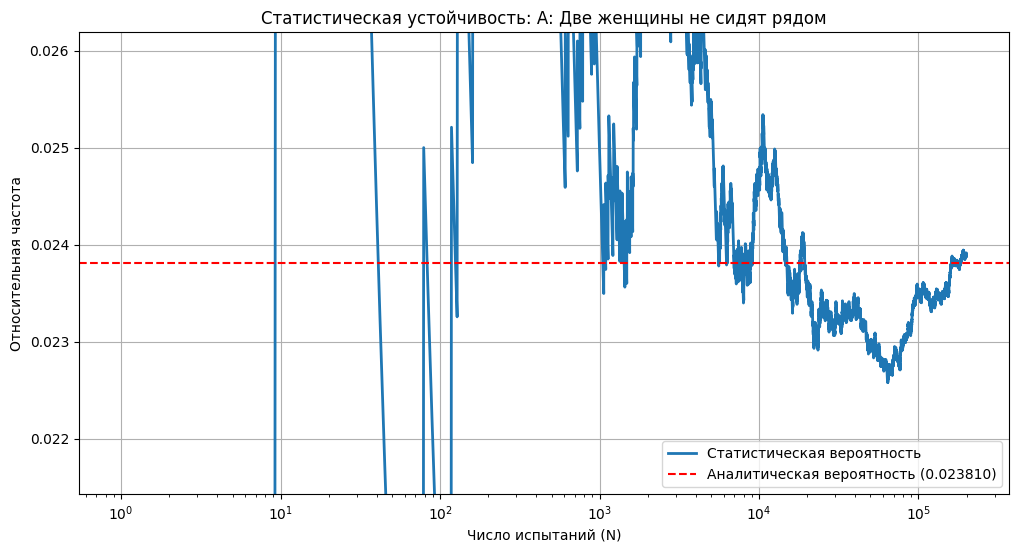

Аналитическая вероятность: 0.023810
Симуляционная вероятность после N=200000 испытаний: 0.023905
--- Событие B: Все мужчины сидят рядом ---


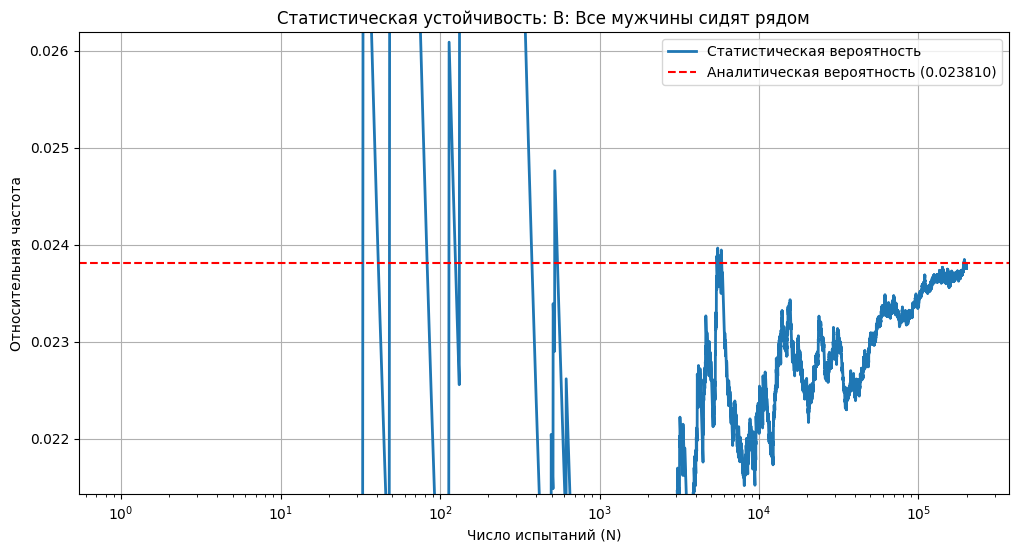

Аналитическая вероятность: 0.023810
Симуляционная вероятность после N=200000 испытаний: 0.023755


In [4]:
def simulate_seating(num_simulations, condition):
    people = np.array(['M']*5 + ['W']*5)
    successes = np.zeros(num_simulations, dtype=bool)
    for i in range(num_simulations):
        np.random.shuffle(people)
        successes[i] = condition(people)
    return np.cumsum(successes) / (np.arange(num_simulations) + 1)

prob_4_2_analytical = (factorial(6) * factorial(5)) / factorial(10)
N_sim_4_2 = 200000

print("--- Событие A: Две женщины не сидят рядом ---")
condition_A_4_2 = lambda arr: np.all(np.diff(np.where(arr == 'W')[0]) > 1)
freq_A_4_2 = simulate_seating(N_sim_4_2, condition_A_4_2)
plot_stability(freq_A_4_2, 'A: Две женщины не сидят рядом', prob_4_2_analytical)

print("--- Событие B: Все мужчины сидят рядом ---")
condition_B_4_2 = lambda arr: (np.max(np.where(arr == 'M')[0]) - np.min(np.where(arr == 'M')[0]) == 4)
freq_B_4_2 = simulate_seating(N_sim_4_2, condition_B_4_2)
plot_stability(freq_B_4_2, 'B: Все мужчины сидят рядом', prob_4_2_analytical)

## Задание 4.3

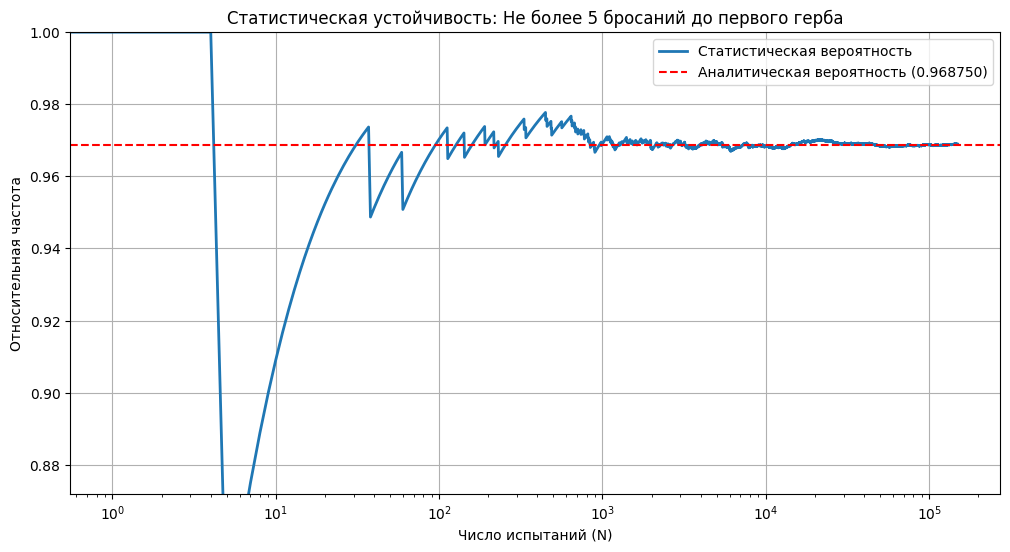

Аналитическая вероятность: 0.968750
Симуляционная вероятность после N=150000 испытаний: 0.968853


In [5]:
def simulate_coin_tosses_4_3(num_simulations):
    tosses = np.random.randint(0, 2, size=(num_simulations, 5))
    successes = np.any(tosses == 1, axis=1)
    return np.cumsum(successes) / (np.arange(num_simulations) + 1)

prob_analytical_4_3 = 1 - (1/2)**5
N_sim_4_3 = 150000
frequencies_4_3 = simulate_coin_tosses_4_3(N_sim_4_3)
plot_stability(frequencies_4_3, 'Не более 5 бросаний до первого герба', prob_analytical_4_3)

## Задание 4.4 и 4.5

--- Задание 4.4: Симметричная монета ---


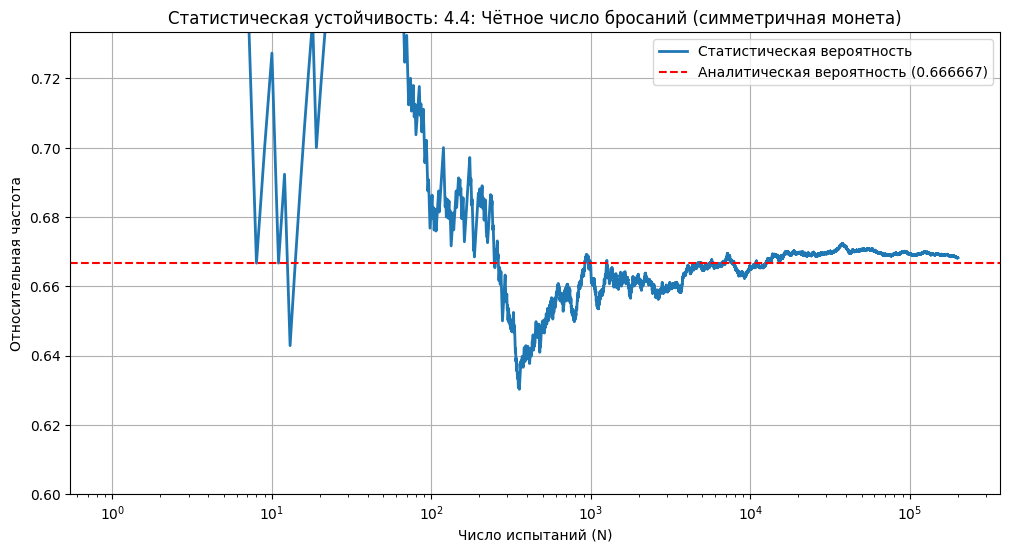

Аналитическая вероятность: 0.666667
Симуляционная вероятность после N=200000 испытаний: 0.668215
--- Задание 4.5: Несимметричная монета (p=0.7) ---


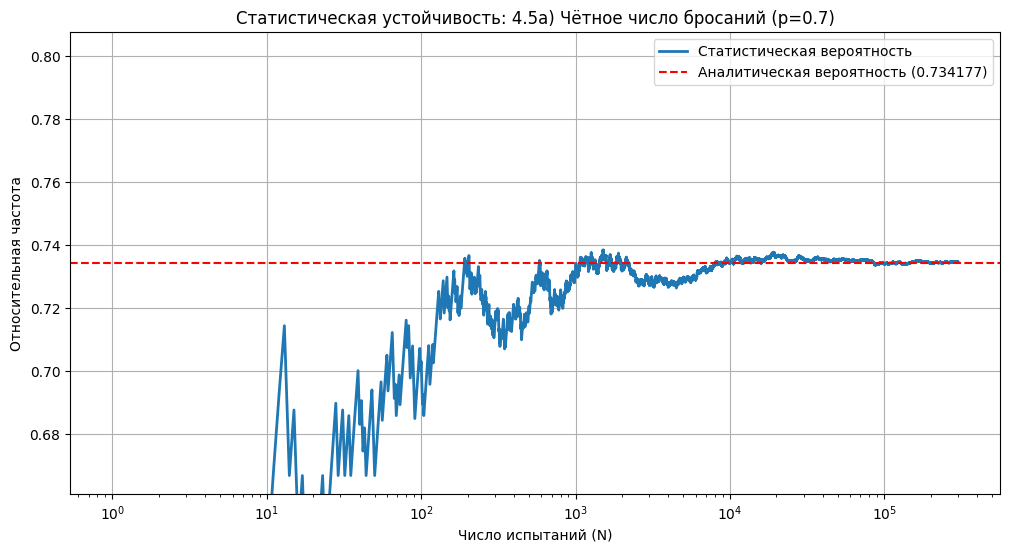

Аналитическая вероятность: 0.734177
Симуляционная вероятность после N=300000 испытаний: 0.734607


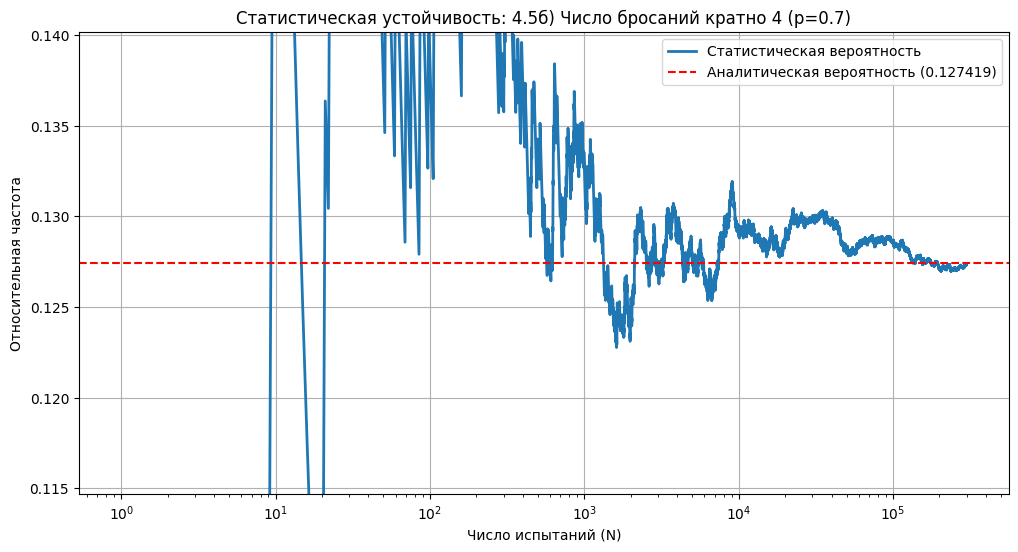

Аналитическая вероятность: 0.127419
Симуляционная вероятность после N=300000 испытаний: 0.127363


In [6]:
def simulate_until_repeat(num_simulations, is_fair=True, p_heads=0.5):
    toss_counts = []
    for _ in range(num_simulations):
        tosses = []
        while len(tosses) < 2 or tosses[-1] != tosses[-2]:
            if is_fair:
                toss = np.random.randint(0, 2)
            else:
                toss = np.random.choice([1, 0], p=[p_heads, 1-p_heads])
            tosses.append(toss)
        toss_counts.append(len(tosses))
    return np.array(toss_counts)

def analyze_toss_counts(toss_counts, condition, analytical_prob, title):
    successes = condition(toss_counts).astype(int)
    relative_frequencies = np.cumsum(successes) / (np.arange(len(toss_counts)) + 1)
    plot_stability(relative_frequencies, title, analytical_prob)

print("--- Задание 4.4: Симметричная монета ---")
prob_analytical_4_4 = 2/3
tosses_4_4 = simulate_until_repeat(200000)
analyze_toss_counts(tosses_4_4, lambda x: x % 2 == 0, prob_analytical_4_4, '4.4: Чётное число бросаний (симметричная монета)')

print("--- Задание 4.5: Несимметричная монета (p=0.7) ---")
p = 0.7
q = 1 - p
prob_even_4_5 = (p**2 + q**2) / (1 - p*q)
prob_mult4_4_5 = ((p**2 + q**2) * (p*q)) / (1 - (p*q)**2)
tosses_4_5 = simulate_until_repeat(300000, is_fair=False, p_heads=p)

analyze_toss_counts(tosses_4_5, lambda x: x % 2 == 0, prob_even_4_5, '4.5а) Чётное число бросаний (p=0.7)')
analyze_toss_counts(tosses_4_5, lambda x: x % 4 == 0, prob_mult4_4_5, '4.5б) Число бросаний кратно 4 (p=0.7)')

## Задание 4.6

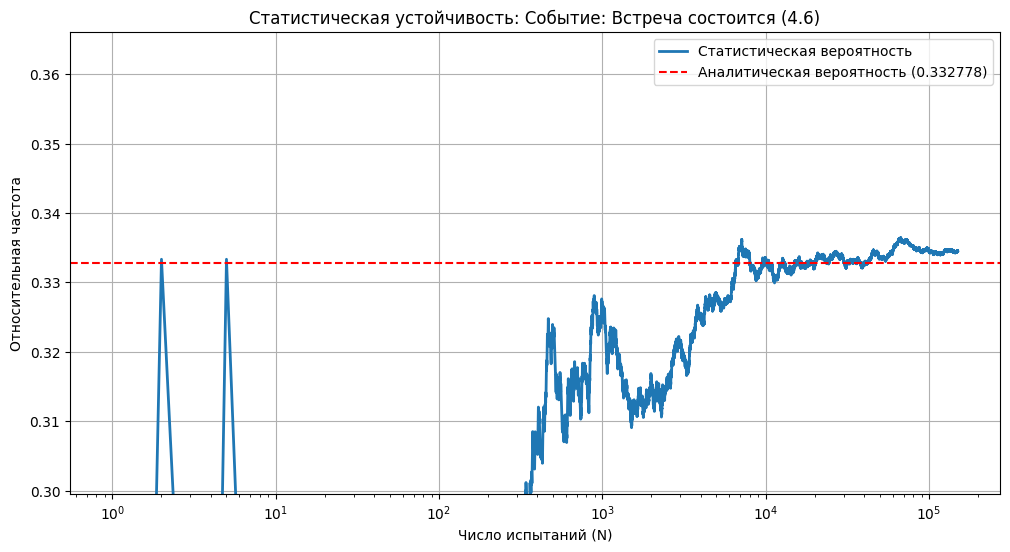

Аналитическая вероятность: 0.332778
Симуляционная вероятность после N=150000 испытаний: 0.334540


In [7]:
def simulate_meeting_4_6(num_simulations):
    t_A = np.random.uniform(0, 60, num_simulations)
    t_B = np.random.uniform(0, 60, num_simulations)
    meet_condition = ((t_B >= t_A) & (t_B <= t_A + 10)) | ((t_A > t_B) & (t_A <= t_B + 12))
    successes = meet_condition.astype(int)
    return np.cumsum(successes) / (np.arange(num_simulations) + 1)

prob_analytical_4_6 = (60**2 - 0.5 * (60 - 10)**2 - 0.5 * (60 - 12)**2) / 60**2
frequencies_4_6 = simulate_meeting_4_6(150000)
plot_stability(frequencies_4_6, 'Событие: Встреча состоится (4.6)', prob_analytical_4_6)

## Задание 4.7

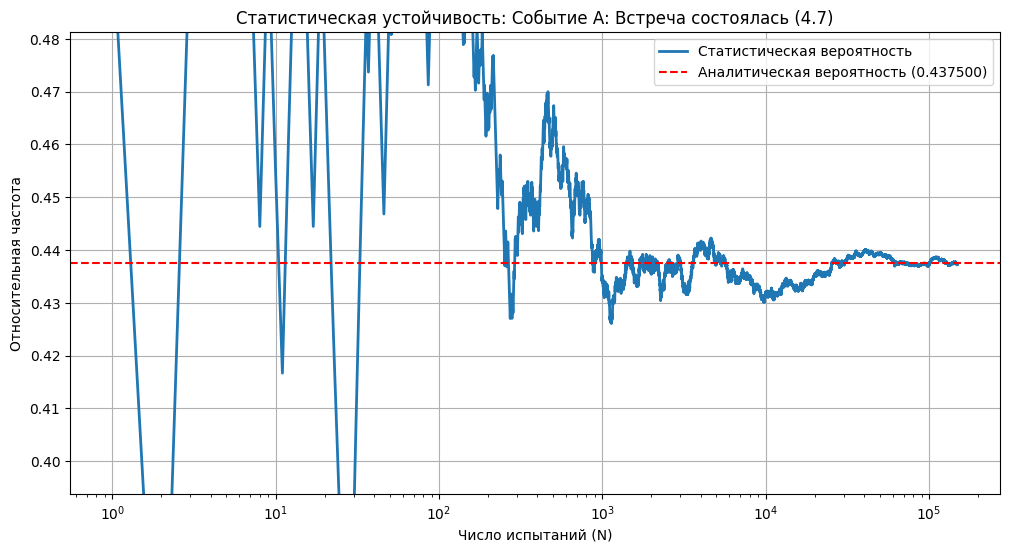

Аналитическая вероятность: 0.437500
Симуляционная вероятность после N=150000 испытаний: 0.437467
Оценка P(B): 0.5625 (Аналитически: 0.5625)
Оценка P(C): 0.5009 (Аналитически: 0.5)
Оценка P(D): 0.1875
Оценка P(E): 0.5009 (Аналитически: 0.5)
Оценка P(F): 0.0418


In [8]:
N_sim_4_7 = 150000
t_ivan = np.random.uniform(0, 60, N_sim_4_7)
t_peter = np.random.uniform(0, 60, N_sim_4_7)
wait_time = 15

event_A = np.abs(t_ivan - t_peter) <= wait_time
event_B = ~event_A
event_C = t_ivan >= t_peter
event_D = event_A & (np.minimum(t_ivan, t_peter) >= 30)
event_E = t_ivan > t_peter
event_F = event_A & (np.maximum(t_ivan, t_peter) > 55)

prob_A_analytical = 1 - ((60 - wait_time) / 60)**2
freq_A = np.cumsum(event_A) / (np.arange(N_sim_4_7) + 1)
plot_stability(freq_A, 'Событие A: Встреча состоялась (4.7)', prob_A_analytical)

print(f"Оценка P(B): {np.mean(event_B):.4f} (Аналитически: {1 - prob_A_analytical:.4f})")
print(f"Оценка P(C): {np.mean(event_C):.4f} (Аналитически: 0.5)")
print(f"Оценка P(D): {np.mean(event_D):.4f}")
print(f"Оценка P(E): {np.mean(event_E):.4f} (Аналитически: 0.5)")
print(f"Оценка P(F): {np.mean(event_F):.4f}")

## Задание 4.8

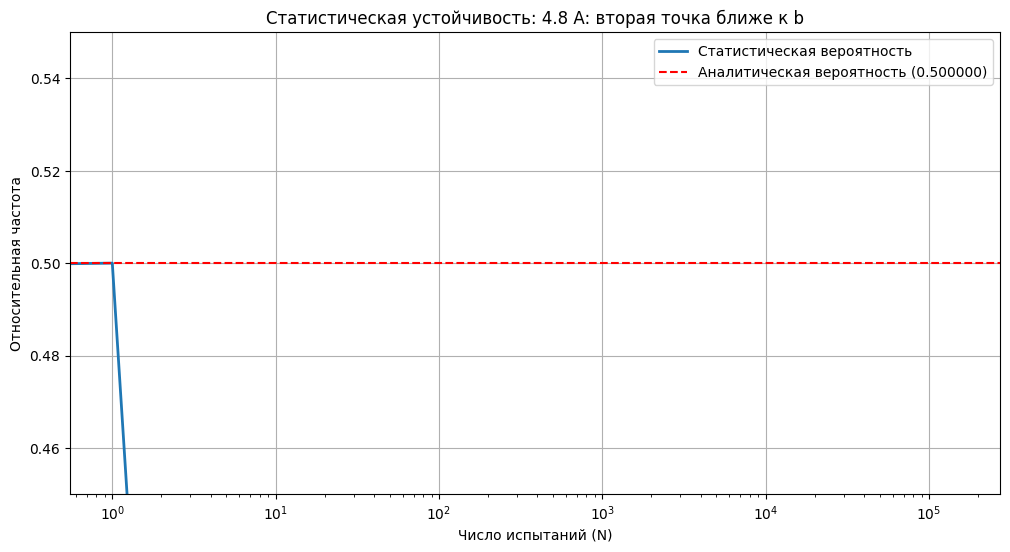

Аналитическая вероятность: 0.500000
Симуляционная вероятность после N=150000 испытаний: 0.307673
Оценка P(B): 0.8461 (Аналитически: 0.75)
Оценка P(C): 0.6921 (Аналитически: 0.5)


In [ ]:
N_sim_4_8 = 150000
x = np.random.uniform(0, 1, N_sim_4_8)
y = np.random.uniform(0, x, N_sim_4_8)

event_A_4_8 = (1 - y) < x
event_B_4_8 = (x - y) < 0.5
event_C_4_8 = (x - y) < (1 - x)

prob_A_analytical_4_8 = 0.5
freq_A_4_8 = np.cumsum(event_A_4_8) / (np.arange(N_sim_4_8) + 1)
plot_stability(freq_A_4_8, '4.8 A: вторая точка ближе к b', prob_A_analytical_4_8)

print(f"Оценка P(B): {np.mean(event_B_4_8):.4f} (Аналитически: 0.75)")
print(f"Оценка P(C): {np.mean(event_C_4_8):.4f} (Аналитически: 0.5)")

## Задание 4.9

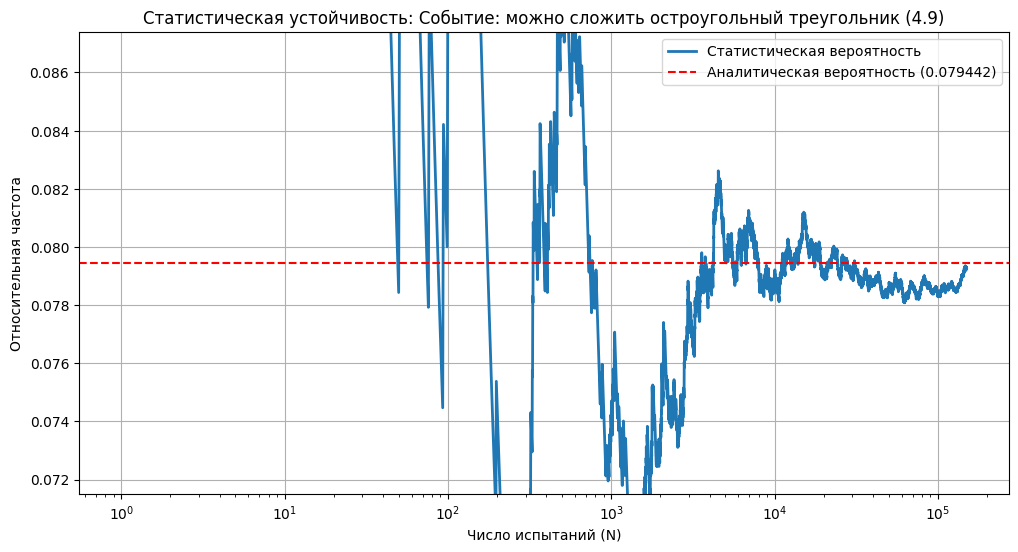

Аналитическая вероятность: 0.079442
Симуляционная вероятность после N=150000 испытаний: 0.079280


In [ ]:
def simulate_triangle_4_9(num_simulations):
    points = np.random.uniform(0, 1, size=(num_simulations, 2))
    points.sort(axis=1)
    l1 = points[:, 0]
    l2 = points[:, 1] - points[:, 0]
    l3 = 1 - points[:, 1]

    sides = np.sort(np.stack([l1, l2, l3], axis=1), axis=1)

    triangle_possible = sides[:, 0] + sides[:, 1] > sides[:, 2]
    acute = (sides[:, 0]**2 + sides[:, 1]**2 > sides[:, 2]**2)

    successes = triangle_possible & acute
    return np.cumsum(successes) / (np.arange(num_simulations) + 1)

prob_analytical_4_9 = 3 * log(2) - 2
N_sim_4_9 = 150000
frequencies_4_9 = simulate_triangle_4_9(N_sim_4_9)
plot_stability(frequencies_4_9, 'Событие: можно сложить остроугольный треугольник (4.9)', prob_analytical_4_9)